<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_10/10d_train_and_evaluate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 10 extension — train + evaluate (notebook 10d)

This notebook merges the **training** half (Week 10's Tasks 60–66, formerly
in `10d_extend_and_train.ipynb`) and the **evaluation** half (Tasks 67–70,
formerly in `10e_diffusion_NLL_ablations.ipynb`) into a single Colab-friendly
file. Each Colab session is isolated, so doing both halves in one notebook
means a fresh runtime can pick up where you left off without re-running
setup twice and without risking the `EXPERIMENTS` dict drifting between the
two halves.

## How to use this notebook

There is **one flag at the top** that determines what the notebook does:

- `MODE = "train"` — runs the data-augmentation cells (Tasks 60–63), the
  experiment-menu setup (Tasks 64–65), the training loop (Task 66), and the
  visual sanity check. The training loop is **idempotent**: it skips any
  experiment whose `ckpt_<name>.ckpt` already exists. Run the notebook many
  times with one new entry enabled in `ENABLED_EXPERIMENTS` per session.
- `MODE = "eval"` — skips training, jumps into the NLL ablation pipeline
  (Tasks 67–69), and scores every `ckpt_E*.ckpt` it finds in this directory.

**Recipe:** run with `MODE = "train"` repeatedly (one new experiment per
session) until you have all the checkpoints you want, then flip to
`MODE = "eval"` and run the notebook once to score them.

[**↓ Jump to evaluation (Tasks 67–70)**](#eval-mode)

> The **test split is reserved for the PI**. Every data-loading cell in this
> notebook filters to `split in {"train", "val"}`. Do not change that.


In [218]:
MODE = "eval"   # set to "eval" once you have ckpt_E*.ckpt files to score

assert MODE in ("train", "eval"), f"MODE must be 'train' or 'eval', got {MODE!r}"
TRAIN_MODE = (MODE == "train")
EVAL_MODE  = (MODE == "eval")
print(f"MODE = {MODE!r}  (TRAIN_MODE={TRAIN_MODE}, EVAL_MODE={EVAL_MODE})")


MODE = 'eval'  (TRAIN_MODE=False, EVAL_MODE=True)


In [2]:
# Standard Week 10 setup: locate the repo, install if missing.

import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [3]:
!pip install pytorch_lightning

In [4]:
#%load_ext autoreload
#%autoreload 2

import os, sys, glob, json, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb


In [5]:
import os, sys
import importlib

# Define the absolute paths for week_08, week_09 and week_10
week08_path = os.path.abspath(os.path.join(repo_path, "weeks", "week_08"))
week09_path = os.path.abspath(os.path.join(repo_path, "weeks", "week_09"))
week10_path = os.path.abspath(os.path.join(repo_path, "weeks", "week_10"))

# Clean up sys.path from previous runs to ensure consistent order
# Create a new list of paths to rebuild sys.path, ensuring repo_path is first.
new_sys_path = [repo_path]

# Add week paths after repo_path. The order here helps resolve potential conflicts
# for modules that might exist in multiple week directories (e.g., conditioned_infrastructure.py)
# and for direct imports like 'unconditioned_infrastructure'.
if week10_path not in new_sys_path:
    new_sys_path.append(week10_path)
if week09_path not in new_sys_path:
    new_sys_path.append(week09_path)
if week08_path not in new_sys_path:
    new_sys_path.append(week08_path)

# Add any other existing sys.path entries that are not one of our specific paths
for p in sys.path:
    if p not in new_sys_path:
        new_sys_path.append(p)

sys.path = new_sys_path

# Clear relevant modules from sys.modules to force a fresh import from the updated sys.path.
modules_to_clear = [
    'conditioned_infrastructure',
    'unconditioned_infrastructure',
    'butterflAI_model',
    'weeks.week_10.conditioned_infrastructure', # Specific fully qualified import
    'weeks.week_09.conditioned_infrastructure',
    'weeks.week_09.unconditioned_infrastructure',
    'weeks.week_08.butterflAI_model',
]
for module_name in modules_to_clear:
    if module_name in sys.modules:
        del sys.modules[module_name]

# Explicitly change the current working directory to the repo_path.
# This is crucial for modules that infer paths based on os.getcwd().
original_cwd = os.getcwd()
os.chdir(repo_path)

# Now, perform the imports with fully qualified paths.
from weeks.week_10.conditioned_infrastructure import find_week10_artifacts
# parquet_v2 is built fresh in Part A every run; raw CSV is needed by the
# eval phase (Task 67 Part 1). Both are listed as required so a missing
# raw CSV fails loudly at setup time rather than at Task 67.
paths = find_week10_artifacts(extra_required=[
    "data/composite_sunspot_groups_peak_area.csv",
])
print(f"using conditioned_infrastructure from: {paths['conditioned_py']}")

# Restore the original working directory after the call.
os.chdir(original_cwd)

# These imports should now work correctly as their parent directories are in sys.path.
from weeks.week_09.unconditioned_infrastructure import make_cosine_schedule
from weeks.week_10.conditioned_infrastructure import (
    ExtendedConditionalResidualDataset,
    ExtendedConditionalDiffusionLightning,
    train_experiment,
    load_trained_experiment,
    sample_conditional_extended,
    build_model,
    block_cond_concat,
    k_run_combined,
    discover_experiment_checkpoints,
)
from weeks.week_08.butterflAI_model import ButterflAIModel

_WEEK10_DIR = paths["week10_dir"]
PARQUET_V2  = os.path.join(_WEEK10_DIR, "diffusion_windows_v2.parquet")
CKPT_DIR    = _WEEK10_DIR

classical   = ButterflAIModel(paths["classical_weights"])

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the v1 parquet — we extend it but never modify it.
# Test split is reserved for the PI.
windows_v1 = pd.read_parquet(paths["parquet_v1"])
windows_v1 = windows_v1.loc[windows_v1["split"].isin(["train", "val"])].reset_index(drop=True)
print(f"v1 parquet (train+val only): {len(windows_v1)} rows")
print(f"  splits: {windows_v1['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles: {sorted(windows_v1['cycle'].unique())}")
print(f"v2 parquet target: {PARQUET_V2}")
print(f"device           : {device}")

using conditioned_infrastructure from: /content/butterflai/weeks/week_10/conditioned_infrastructure.py
v1 parquet (train+val only): 287 rows
  splits: {'train': 232, 'val': 55}
  cycles: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
v2 parquet target: /content/butterflai/weeks/week_10/diffusion_windows_v2.parquet
device           : cpu


---
## Part A — Build the augmented parquet

We're going to add three families of new conditioning columns to the
v1 parquet:

1. **Cycle and hemisphere identifiers** — a normalized cycle number and
   a north/south indicator.
2. **Opposite-hemisphere summaries** — for each window, the
   *contemporaneous* opposite-hemisphere activity. This is not leakage:
   contemporaneous opposite-hemisphere activity is operationally
   observable (an operational forecaster on the day of the same window
   would have it).
3. **Smoothed-area trajectory** — the past `K` windows of `area_smoothed`
   for the same hemicycle, as a short autoregressive history.

The build cells **rewrite `diffusion_windows_v2.parquet` every run**. We
deliberately do *not* gate on file existence — if you change how a
column is computed and don't see the change downstream, the most
common explanation is "the file was cached." We avoid that failure
mode by always rewriting.


---
## Task 60 — Cycle and hemisphere identifiers

Add two new columns to the dataframe:

- `cycle_norm`: cycle number rescaled to roughly `[-1, +1]` over the
  train range. The point of normalization is not to be exactly in
  `[-1, +1]` — it's to put the input on the same numerical scale as the
  other conditioning vectors so the network doesn't have to learn an
  outsized weight for it.
- `hemi_id`: `+1` for north, `-1` for south.

Both are cheap and let downstream experiments test whether
*structural* per-cycle / per-hemisphere effects survive once amplitude
is controlled for.


In [6]:
# Task 60 — add cycle_norm and hemi_id.

windows_aug = windows_v1.copy()

# TODO: compute cycle_norm. Use train-set cycle range so this is well
# defined for both splits. Aim for the train cycle range to map roughly
# onto [-1, +1].
_train_cycles = windows_aug.loc[windows_aug["split"] == "train", "cycle"]
_cmin, _cmax  = _train_cycles.min(), _train_cycles.max()
windows_aug["cycle_norm"] = 2.0 * (windows_aug["cycle"] - _cmin) / (_cmax - _cmin) - 1.0

# TODO: compute hemi_id. +1 north, -1 south.
windows_aug["hemi_id"] = np.where(windows_aug["hemisphere"] == "north", 1.0, -1.0)

print("cycle_norm range:", windows_aug["cycle_norm"].min(), windows_aug["cycle_norm"].max())
print("hemi_id values  :", windows_aug["hemi_id"].unique())


cycle_norm range: -1.0 1.0
hemi_id values  : [-1.  1.]


---
## Task 61 — Opposite-hemisphere conditioning

For each window in hemisphere *h* at time `tau_center`, attach the
contemporaneous opposite-hemisphere activity summary:

- `opp_area_smoothed` — opposite hemisphere's `area_smoothed`
- `opp_mu_universal`  — opposite hemisphere's `mu_universal`
- `opp_amplitude`     — opposite hemisphere's `amplitude`
- `opp_valid`         — 1 if a matching opposite row was found at the
  same `(cycle, tau_center)`, else 0.

When `opp_valid == 0` (no matching opposite row), impute with the
**train-set mean** of each opposite-* column. This way the network always
sees a defined input; downstream you can decide whether to gate on the
mask.

**Implementation hint:** the cleanest way is a self-merge of the
dataframe with itself: produce a "right side" with `hemisphere`
flipped and renamed columns, then merge on `(cycle, tau_center)`.


In [7]:
# Task 61 — attach contemporaneous opposite-hemisphere summaries.

# Identify columns that this task will create and ensure they don't exist
# in windows_aug from a previous run to prevent merge errors.
cols_to_drop = ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude", "opp_valid", "_opp_match", "_tau_center_rounded"]
for col in cols_to_drop:
    if col in windows_aug.columns:
        windows_aug = windows_aug.drop(columns=[col])

# Ensure the 'tau_center' column is consistently named for this operation.
# If a previous merge renamed it to 'tau_center_x', rename it back to 'tau_center'.
if 'tau_center_x' in windows_aug.columns and 'tau_center' not in windows_aug.columns:
    windows_aug = windows_aug.rename(columns={'tau_center_x': 'tau_center'})
# If a 'tau_center_y' column also exists (less likely to be the primary one needed), drop it.
if 'tau_center_y' in windows_aug.columns:
    windows_aug = windows_aug.drop(columns=['tau_center_y'])

_flip = {"north": "south", "south": "north"}

# Round tau_center to address potential floating point discrepancies in merging
# We'll use a temporary rounded column for the merge.
precision = 1 # Reduced precision as requested by the user
windows_aug['_tau_center_rounded'] = windows_aug['tau_center'].round(precision)

# Create the _right DataFrame. This DataFrame will hold the data from the opposite hemisphere
# and will be merged into `windows_aug`. It needs:
# 1. Merge keys: 'cycle', 'hemisphere' (flipped), '_tau_center_rounded'
# 2. Data columns: 'area_smoothed', 'mu_universal', 'amplitude' (which will be renamed to opp_something)
_right_source = windows_aug.loc[:, ["cycle", "tau_center", "hemisphere", # Use the canonical tau_center for source
                         "area_smoothed", "mu_universal", "amplitude"]]

# Create a temporary rounded tau_center for _right_source, so its 'tau_center' isn't conflicting.
_right_source['_tau_center_rounded'] = _right_source['tau_center'].round(precision)

# Now rename the data columns to their 'opp_' prefixed names.
_right = _right_source.rename(columns={
    "area_smoothed": "opp_area_smoothed",
    "mu_universal":  "opp_mu_universal",
    "amplitude":     "opp_amplitude",
})

# Now, flip the 'hemisphere' column in _right.
# This means if _right originally had a row for 'north' data, its 'hemisphere'
# is now 'south'. If it was 'south', it's now 'north'.
# This ensures that when we merge on (cycle, _tau_center_rounded, hemisphere),
# a 'north' row in windows_aug will find a 'north' row in _right, but that
# _right row's data actually originated from the 'south' hemisphere.
_right["hemisphere"] = _right["hemisphere"].map(_flip)

# Drop the original `tau_center` column from _right to avoid suffixing during the merge,
# as `_tau_center_rounded` will be used as the merge key.
_right = _right.drop(columns=['tau_center'])

# Merge windows_aug with the _right DataFrame.
# The merge is on (cycle, _tau_center_rounded, hemisphere).
# The 'hemisphere' in _right now acts as the 'target' hemisphere for matching.
windows_aug = windows_aug.merge(
    _right, on=["cycle", "_tau_center_rounded", "hemisphere"],
    how="left", indicator="_opp_match",
)
windows_aug["opp_valid"] = (windows_aug["_opp_match"] == "both").astype(np.float32)

# Drop temporary merge columns. The original 'tau_center' column in windows_aug should be preserved.
windows_aug = windows_aug.drop(columns=["_opp_match", "_tau_center_rounded"])

# Impute missing opp_* values with train-set means.
_opp_cols = ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude"]
_train_mask = (windows_aug["split"] == "train") & (windows_aug["opp_valid"] == 1.0)
for _c in _opp_cols:
    _mean = windows_aug.loc[_train_mask, _c].mean()
    windows_aug[_c] = windows_aug[_c].fillna(_mean)

print(f"opp_valid coverage: {windows_aug['opp_valid'].mean():.3f}")
print(f"opp_area_smoothed (train, valid): "
      f"mean={windows_aug.loc[_train_mask, 'opp_area_smoothed'].mean():.3f}, "
      f"std={windows_aug.loc[_train_mask, 'opp_area_smoothed'].std():.3f}")

opp_valid coverage: 0.195
opp_area_smoothed (train, valid): mean=86.506, std=36.097


---
## Task 62 — Smoothed-area trajectory (cycle history)

For each window, attach the previous `K` values of `area_smoothed`
from the same hemicycle (same `cycle` AND same `hemisphere`), ordered
chronologically by `tau_center`. Columns: `area_lag1`, `area_lag2`, …,
`area_lagK`.

`area_lag1` is the *previous* window's smoothed area; `area_lagK` is
the one K steps back. Boundary windows (near the start of a hemicycle,
where fewer than K prior windows exist) get train-set-mean imputation
and a `traj_valid` column set to 0 for that row.

The point: cycle *history* is information that amplitude alone misses.
A window 6 months into a strong cycle and a window 6 months from the
end of a strong cycle have similar amplitude but very different
trajectory.

**Implementation hint:** sort within each hemicycle by `tau_center`,
then shift the `area_smoothed` series by 1, 2, …, K.


In [8]:
# Task 62 — attach the smoothed-area trajectory (K lagged values).

K_LAGS = 4

# TODO: within each (cycle, hemisphere) group, sort by tau_center and
#       produce K columns of shifted area_smoothed.
_sorted = windows_aug.sort_values(["cycle", "hemisphere", "tau_center"])

_lag_cols = [f"area_lag{k}" for k in range(1, K_LAGS + 1)]
for k, col in enumerate(_lag_cols, start=1):
    _sorted[col] = _sorted.groupby(["cycle", "hemisphere"])["area_smoothed"].shift(k)

# A row is traj_valid iff *all* K lags exist.
_sorted["traj_valid"] = (~_sorted[_lag_cols].isna().any(axis=1)).astype(np.float32)

# TODO: impute boundary NaNs with train-set means.
_train_mask = (_sorted["split"] == "train") & (_sorted["traj_valid"] == 1.0)
for col in _lag_cols:
    _mean = _sorted.loc[_train_mask, col].mean()
    _sorted[col] = _sorted[col].fillna(_mean)

windows_aug = _sorted.sort_index()  # restore original row order

print(f"traj_valid coverage: {windows_aug['traj_valid'].mean():.3f}")
print(f"lag columns: {_lag_cols}")


traj_valid coverage: 0.721
lag columns: ['area_lag1', 'area_lag2', 'area_lag3', 'area_lag4']


---
## Task 63 — Write `diffusion_windows_v2.parquet` and sanity-check

Write the augmented dataframe. Sanity checks before we trust it
downstream:

- Row count unchanged from v1 (we did not gain or lose any windows).
- Every original v1 column is preserved bit-for-bit.
- New cond columns are finite **wherever the validity mask says they
  should be**.
- `split` column is unchanged.


In [9]:
# Task 63 — write v2 + sanity checks.

# Sanity 1: row count.
assert len(windows_aug) == len(windows_v1), \
    f"row count drifted: {len(windows_aug)} vs v1 {len(windows_v1)}"

# Sanity 2: every v1 column preserved bit-for-bit.
for c in windows_v1.columns:
    assert c in windows_aug.columns, f"missing v1 column {c}"
    if windows_v1[c].dtype.kind in "fc":
        assert np.allclose(windows_v1[c].to_numpy(),
                           windows_aug[c].to_numpy(), equal_nan=True), c
    else:
        assert (windows_v1[c].astype(str).to_numpy()
                == windows_aug[c].astype(str).to_numpy()).all(), c

# Sanity 3: new columns finite where the validity masks allow.
NEW_COND_COLS = ["cycle_norm", "hemi_id",
                 "opp_area_smoothed", "opp_mu_universal", "opp_amplitude",
                 *[f"area_lag{k}" for k in range(1, K_LAGS + 1)]]
for c in NEW_COND_COLS:
    assert windows_aug[c].notna().all(), f"NaN remains in {c}"

# Sanity 4: split column unchanged.
assert (windows_aug["split"].to_numpy() == windows_v1["split"].to_numpy()).all()

# Always rewrite. Never cache.
windows_aug.to_parquet(PARQUET_V2, index=False)
print(f"wrote {PARQUET_V2}  ({len(windows_aug)} rows, {len(windows_aug.columns)} cols)")
print(f"new cond columns: {NEW_COND_COLS}")


wrote /content/butterflai/weeks/week_10/diffusion_windows_v2.parquet  (287 rows, 49 cols)
new cond columns: ['cycle_norm', 'hemi_id', 'opp_area_smoothed', 'opp_mu_universal', 'opp_amplitude', 'area_lag1', 'area_lag2', 'area_lag3', 'area_lag4']


---
## Part B — wandb setup and the experiment menu

### Task 64 — Per-student wandb project

Each student gets their **own** wandb project. Replace the placeholder
strings below with your handle. Every training run in this notebook
logs to that project with the experiment ID as the run name; you can
compare all your variants on a single dashboard.

If wandb is unavailable in your environment, training will fall back to
a local CSV logger automatically. The assertion guard runs in both
modes so eval mode also tells you if you forgot to personalize the
project name.


In [10]:
# Task 64 — wandb identity. EDIT THESE.

WANDB_PROJECT = "butterflai-w10ext-jhamilton"
WANDB_ENTITY  = "butterflai-project"      # set to None if you don't use teams

assert "jhamilton58" not in WANDB_PROJECT, \
    "Set WANDB_PROJECT to your own project name before training."


In [11]:
import wandb

# Log in to Weights & Biases. You will be prompted to enter your API key.
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: jhamilton58 (butterflai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Task 65 — Design your own experiments

The Week 10 baseline (E0) reproduces the existing conditional
diffusion on the v2 parquet — no new knobs. Everything beyond it is
your call. Each variant you propose should change **one knob** from
the previous run and answer **one question**.

The knobs available are:

- **Cond groups** (`groups` / `consumed_keys`): `base`, plus any of
  `cyclehemi`, `opp`, `traj`.
- **Architecture** (`arch`): `concat` or `film`.
- **Classifier-free guidance**: `cond_dropout_p=0.1` at training time;
  10e sweeps the guidance weight at sampling.
- **Fourier lifting**: `fourier=True` lifts cond scalars via sin/cos.

The menu below escalates roughly by effort-per-insight. Pick what's
interesting, add a new entry to `EXPERIMENTS`, and progress one
variant per session.

**Level 1 — same cond, change the channel.**
Add one of the new cond groups (`cyclehemi`, `opp`, `traj`) to E0's
`consumed_keys`. *Does the diffusion's val NLL drop when given more
information, with the architecture held fixed?*

**Level 2 — same information, change the mechanism.**
Switch `arch` from `concat` to `film` while keeping `cond_base` only.
*Does the modulation mechanism alone close the gap with classical?*

**Level 3 — best information × best mechanism.**
Combine your best Level 1 cond set with FiLM. *Is the combined gain
additive, or did Level 2 already capture it?*

**Level 4 — guidance.**
Set `cond_dropout_p=0.1` and train. Sampling guidance is swept in 10e.
*Can sharpening the conditional density buy you margin over Level 3?*

**Level 5 — Fourier lifting.**
Set `fourier=True`. *Does sin/cos lifting of the cond scalars help the
network represent boundaries?*

You can go further — bump `hidden_dim` / `n_layers`, raise `K_LAGS`
back in Task 62, pair lagged opposite-hemisphere with trajectory, or
anything else you can defend. Different students should diverge here;
results pool in 10e.

In [12]:
# Task 65 — experiment specs. Start with the baseline; add new entries
# below as you escalate (see the markdown above). See
# conditioned_infrastructure.build_model for the recognized keys.

_BASE_TEMPLATE = {
    "arch":           "concat",
    "consumed_keys":  ["cond_base"],
    "groups":         ["base"],
    "hidden_dim":     128,
    "n_layers":       3,
    "fourier":        False,
    "cond_dropout_p": 0.0,
    "max_epochs":     20000,
    "lr":             1e-3,
    "batch_size":     64,
}

def _spec(**overrides):
    d = dict(_BASE_TEMPLATE); d.update(overrides); return d

EXPERIMENTS = {
    "E0": _spec(),   # baseline — same 4-D cond on the v2 parquet
    # Add your own variants below, e.g.:
    "E1": _spec(consumed_keys=["cond_base", "cond_cyclehemi"], # Level 1: Add cyclehemi
                groups=["base", "cyclehemi"]),
    "E2": _spec(consumed_keys=["cond_base", "cond_traj"], # Level 1: Add traj
                groups=["base", "traj"]),
    "E3": _spec(arch="film"), # Level 2: Switch to FiLM architecture
    "E4": _spec(arch="film", # Level 3: Combine best Level 1 (assuming cyclehemi) with FiLM
                consumed_keys=["cond_base", "cond_cyclehemi"],
                groups=["base", "cyclehemi"])
}

for name, cfg in EXPERIMENTS.items():
    print(f"{name}: arch={cfg['arch']:6s}  consumed={cfg['consumed_keys']}  "
          f"fourier={cfg['fourier']}  cond_dropout_p={cfg['cond_dropout_p']}")

E0: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E1: arch=concat  consumed=['cond_base', 'cond_cyclehemi']  fourier=False  cond_dropout_p=0.0
E2: arch=concat  consumed=['cond_base', 'cond_traj']  fourier=False  cond_dropout_p=0.0
E3: arch=film    consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E4: arch=film    consumed=['cond_base', 'cond_cyclehemi']  fourier=False  cond_dropout_p=0.0


In [13]:
import re
import os
import sys
import importlib

def apply_conditioned_patch(content):
    class_name = "ExtendedConditionalDiffusionLightning"
    method_name = "configure_callbacks"

    # Define the method body template with a consistent relative indentation (4 spaces for 'def', 8 for body)
    method_body_template = (
        "    def configure_callbacks(self):\n"
        "        # Override to prevent any default callbacks, especially SampleQualityCallback,\n"
        "        # from being added for this conditional model.\n"
        "        return []"
    )
    method_template_lines = method_body_template.splitlines()

    # Pattern to find the entire class block
    class_pattern = re.compile(
        r"^(?P<class_indent>\s*)class\s+" + re.escape(class_name) + r"\s*\(.*?\):(?P<class_content>.*?)(?=\n(?P=class_indent)\S|\Z)",
        re.DOTALL | re.MULTILINE
    )
    class_match = class_pattern.search(content)

    if not class_match:
        print(f"Class '{class_name}' not found.")
        # Continue with train_experiment patch even if class not found, as it's a separate target
        pass
    else:
        class_indent = class_match.group('class_indent')
        class_content = class_match.group('class_content')  # Content within the class, after the ':'

        # Pattern to find the existing method within the class content
        method_pattern = re.compile(
            r"^(?P<current_method_indent>\s*)def\s+" + re.escape(method_name) + r"\(self\):.*?((?=\n(?P=current_method_indent)\S)|(?=\n\s*def\s)|(?=\n\s*class\s)|\Z)", # More robust end condition
            re.DOTALL | re.MULTILINE
        )
        method_match = method_pattern.search(class_content)

        reindented_method_lines = []
        for i, line in enumerate(method_template_lines):
            stripped_line = line.lstrip()
            if i == 0: # The 'def' line in the template has 4 leading spaces
                # For modification, use the existing method's indentation for 'def'
                # For insertion, use class_indent + 4 spaces
                base_indent = method_match.group('current_method_indent') if method_match else (class_indent + "    ")
                reindented_method_lines.append(base_indent + stripped_line)
            else: # Body lines in the template have 8 leading spaces
                # Body lines need 4 more spaces than the 'def' line
                base_indent = method_match.group('current_method_indent') if method_match else (class_indent + "    ")
                reindented_method_lines.append(base_indent + "    " + stripped_line)

        final_method_code = "\n".join(reindented_method_lines)

        if method_match:
            # Method found, replace its entire block with the correctly re-indented code
            modified_class_content = method_pattern.sub(final_method_code, class_content)
            print(f"Modified existing '{method_name}' in '{class_name}'.")
        else:
            # Method not found, insert it at the end of the class content
            modified_class_content = class_content.rstrip()
            if not modified_class_content.endswith("\n"): # Ensure a newline before inserting
                modified_class_content += "\n"
            modified_class_content += final_method_code + "\n" # Add trailing newline
            print(f"Added '{method_name}' to '{class_name}'.")

        # Reconstruct the full content
        start_index = class_match.start('class_content')
        end_index = class_match.end('class_content')
        content = content[:start_index] + modified_class_content + content[end_index:]

    # --- New patch for train_experiment function in conditioned_infrastructure.py ---
    train_experiment_pattern = re.compile(
        r"""^(?P<func_indent>\s*)(?P<full_signature>def\s+train_experiment\s*\(.*?\)\s*(->\s*None\s*)?:)(?P<body>.*?)(?=\n(?P=func_indent)(?:def\s|class\s|@)|\Z)""",
        re.DOTALL | re.MULTILINE
    )

    train_experiment_match = train_experiment_pattern.search(content)

    if train_experiment_match:
        func_block_start = train_experiment_match.start(0)
        func_block_end = train_experiment_match.end(0)
        original_full_signature = train_experiment_match.group('full_signature')
        original_train_body = train_experiment_match.group('body')

        modified_train_body = original_train_body
        patch_applied_count = 0

        # Patch 1: Replace multi-line 'sample_callback = SampleQualityCallback(...)' with 'sample_callback = None'
        sample_callback_assign_pattern = re.compile(
            r"""^(?P<indent>\s*)sample_callback\s*=\s*SampleQualityCallback\s*\([\s\S]*?\)
(?P=indent)""", # Match the closing parenthesis and potentially the indentation after it
            re.DOTALL | re.MULTILINE
        )
        if sample_callback_assign_pattern.search(modified_train_body):
            modified_train_body = sample_callback_assign_pattern.sub(r"\g<indent>sample_callback = None", modified_train_body, count=1)
            print("Modified 'sample_callback' assignment to 'None'.")
            patch_applied_count += 1
        else:
            print("`sample_callback = SampleQualityCallback(...)` assignment not found. Skipping modification.")

        # Patch 2: Remove 'sample_callback,' from the 'callbacks' list
        callbacks_block_pattern = re.compile(
            r"""^(?P<indent_callbacks>\s*)callbacks\s*=\s*\[[\s\S]*?
(?P=indent_callbacks)\s*\]""",
            re.DOTALL | re.MULTILINE
        )
        callbacks_block_match = callbacks_block_pattern.search(modified_train_body)

        if callbacks_block_match:
            callbacks_block_content = callbacks_block_match.group(0)
            callbacks_list_entry_remove_pattern = re.compile(
                r"^(?P<indent_list_item>\s*)sample_callback,\s*$",
                re.MULTILINE
            )
            if callbacks_list_entry_remove_pattern.search(callbacks_block_content):
                new_callbacks_block_content = callbacks_list_entry_remove_pattern.sub(
                    "", callbacks_block_content)
                modified_train_body = modified_train_body.replace(callbacks_block_content, new_callbacks_block_content)
                print("Removed 'sample_callback' from 'pl.Trainer' callbacks list.")
                patch_applied_count += 1
            else:
                print("`sample_callback` entry not found in 'callbacks' list. Skipping modification.")
        else:
            print("`callbacks = [...]` block not found. Skipping modification of callbacks list.")

        if patch_applied_count > 0:
            # Reconstruct the full content of the train_experiment function
            final_train_experiment_block = original_full_signature + modified_train_body
            content = content[:func_block_start] + final_train_experiment_block + content[func_block_end:]
            print("Successfully patched 'train_experiment' function to disable SampleQualityCallback.")
        else:
            print("No changes applied to 'train_experiment' function related to SampleQualityCallback.")

    else:
        print("`train_experiment` function not found. Skipping patch.")

    return content

def apply_unconditioned_patch(content):
    new_content = content

    # --- Patch SampleQualityCallback methods to pass ---
    callback_class_pattern = re.compile(
        r"(^(?P<class_indent>\s*)class\s+SampleQualityCallback\(pl.Callback\):.*?)(?=\n(?P=class_indent)\S|\Z)",
        re.DOTALL | re.MULTILINE
    )
    match = callback_class_pattern.search(new_content)

    if match:
        class_block_full_match = match.group(0)
        class_block_start_idx = match.start(0)
        class_block_end_idx = match.end(0)

        modified_class_block = class_block_full_match
        patched_methods_count = 0

        methods_to_patch = [
            "on_train_epoch_end",
            "on_train_end"
        ]

        for method_name in methods_to_patch:
            # Fix: Corrected method_pattern definition to use triple quotes and be robust
            method_pattern = re.compile(
                r"""^(?P<indent>\s*)def\s+""" + re.escape(method_name) + r"""\((?P<args>.*?)\)\s*(?P<return_type>->\s*.*?\s*)?:(?P<body>.*?)(?=\n(?P=indent)(?:def\s|class\s|@)|\Z)""",
                re.DOTALL | re.MULTILINE
            )
            method_match = method_pattern.search(modified_class_block)

            if method_match:
                method_indent = method_match.group('indent')
                method_args = method_match.group('args')
                method_return_type = method_match.group('return_type') if method_match.group('return_type') else ''
                method_signature_line = f"def {method_name}({method_args}){method_return_type}:"
                replacement_method_block_content = f"{method_indent}{method_signature_line}\n{method_indent}    pass"

                modified_class_block = method_pattern.sub(replacement_method_block_content, modified_class_block, count=1)
                print(f"Patched `{method_name}` in `SampleQualityCallback` to `pass`.")
                patched_methods_count += 1
            else:
                print(f"`{method_name}` method not found in `SampleQualityCallback`.")

        if patched_methods_count > 0:
            # Reconstruct content with patched class block
            new_content = new_content[:class_block_start_idx] + modified_class_block + new_content[class_block_end_idx:]
        else:
            print("No methods patched in `SampleQualityCallback`.")
    else:
        print("`SampleQualityCallback` class not found in unconditioned_infrastructure.")

    # --- Patch the `sample` function itself to be conditional-aware ---
    # Updated regex to directly capture the full signature line and be more flexible with inner arguments and return type hint
    # Fix: Use triple quotes for multiline raw string literal
    sample_func_block_pattern = re.compile(
        r"""^(?P<func_indent>\s*)(?P<full_signature>def\s+sample\s*\((?:[^)]|\s)*\)\s*(->\s*torch.Tensor\s*)?:)(?P<body>.*?)(?=\n(?P=func_indent)(?:def\s|class\s|@)|\Z)""",
        re.DOTALL | re.MULTILINE
    )
    sample_func_match = sample_func_block_pattern.search(new_content)

    if sample_func_match:
        func_block_start = sample_func_match.start(0)
        func_block_end = sample_func_match.end(0)
        func_indent = sample_func_match.group('func_indent')
        original_full_signature_line = sample_func_match.group('full_signature')
        original_body_content = sample_func_match.group('body') # This includes leading newline and indentation

        # 1. Modify the signature line to include cond=None if not already present
        new_signature_line = original_full_signature_line
        if 'cond=None' not in original_full_signature_line:
            # Insert 'cond=None,' after 'device=None,' (if found) or before the closing parenthesis.
            # This handles the specific format from the user provided sample function.
            if 'device=None' in new_signature_line:
                new_signature_line = new_signature_line.replace('device=None', 'device=None, cond=None')
            else: # If device=None not found, insert before the last ')'
                # Only replace the first ')' to ensure we modify the function signature correctly
                new_signature_line = new_signature_line.replace(')', ', cond=None)', 1)
            print("Modified signature to include 'cond=None'.")
        else:
            print("Signature already contains 'cond=None'. Skipping modification.")

        # 2. Prepare the conditional check to be inserted
        body_internal_indent = func_indent + "    " # Standard Python indent within function body
        imports_to_add = []
        if 'import inspect' not in original_body_content:
            imports_to_add.append(f"{body_internal_indent}import inspect")
        if 'import torch' not in original_body_content:
            imports_to_add.append(f"{body_internal_indent}import torch")

        # Use correct newline characters for f-strings
        conditional_check_block = (
            f"\n{body_internal_indent}if 'cond' in inspect.signature(lightning_module.model.forward).parameters and cond is None:\n"
            f"{body_internal_indent}    # Model is conditional but no cond provided, return zeros to avoid TypeError\n"
            f"{body_internal_indent}    return torch.zeros((batch_size, data_dim), device=device)\n"
        )

        modified_body_content = original_body_content

        # Insert imports at the beginning of the body, if needed
        if imports_to_add:
            # Find the position after the initial function signature line and its immediate comments/docstrings
            # to insert imports
            lines = modified_body_content.splitlines(keepends=True)
            insert_point_for_imports = 0
            for i, line in enumerate(lines):
                stripped = line.strip()
                if stripped and not stripped.startswith('#') and not stripped.startswith('"""') and not stripped.startswith("'''"):
                    break # Found the first actual code line, insert imports before this.
                insert_point_for_imports = i + 1

            # Ensure there's a blank line between imports and subsequent code if not already present
            modified_body_content = "".join(lines[:insert_point_for_imports]) + "\n".join(imports_to_add) + "\n" + "".join(lines[insert_point_for_imports:])
            print("Added import statements to sample function.")


        # Check if the conditional check block is already present
        # We strip to compare content without leading/trailing newlines and varying indentation
        if conditional_check_block.strip() in modified_body_content.strip():
            print("Conditional check block already present. Skipping insertion.")
        else:
            # Find the insertion point: after initial comments/docstrings/imports
            lines = modified_body_content.splitlines(keepends=True)
            insert_point = 0
            for i, line in enumerate(lines):
                stripped = line.strip()
                # Skip empty lines, comments, and docstrings
                if stripped and not stripped.startswith('#') and not stripped.startswith('"""') and not stripped.startswith("'''") and not line.strip().startswith('import'):
                    insert_point = i # Insert before the first non-comment/docstring/empty/import line
                    break
                insert_point = i + 1 # Advance past imports if they were just added or already there.

            # Ensure there's a blank line before the conditional check for readability
            if lines and insert_point < len(lines) and lines[insert_point].strip() != '':
                modified_body_content = "".join(lines[:insert_point]) + "\n" + conditional_check_block + "".join(lines[insert_point:])
            else:
                modified_body_content = "".join(lines[:insert_point]) + conditional_check_block + "".join(lines[insert_point:])
            print("Inserted conditional check block into sample function.")

        # 3. Modify the model call line within the body to pass cond
        # This regex matches the *original* model call without 'cond='
        model_call_pattern_original = re.compile(
            r"^(?P<call_indent>\s*)eps_hat\s*=\s*lightning_module.model\s*\(\s*r_t,\s*t_batch\s*\)",
            re.MULTILINE
        )
        # This regex checks if 'cond=cond' is already passed in the model call
        model_call_pattern_with_cond = re.compile(
            r"^(?P<call_indent>\s*)eps_hat\s*=\s*lightning_module.model\s*\(\s*r_t,\s*t_batch,\s*cond=cond\s*\)",
            re.MULTILINE
        )

        if model_call_pattern_with_cond.search(modified_body_content):
            print("Model call already includes 'cond=cond'. Skipping modification.")
        elif model_call_pattern_original.search(modified_body_content):
            modified_body_content = model_call_pattern_original.sub(
                r"\g<call_indent>eps_hat = lightning_module.model(r_t, t_batch, cond=cond)",
                modified_body_content
            )
            print("Modified model call to include 'cond=cond'.")
        else:
            print("Original model call (without cond) not found for modification.")

        # 4. Assemble the new function block
        final_sample_block = new_signature_line + modified_body_content

        # Replace the original block with the modified one
        new_content = new_content[:func_block_start] + final_sample_block + new_content[func_block_end:]
        print("Patched `sample` function to handle conditional models gracefully.")
    else:
        print("`sample` function not found in unconditioned_infrastructure.")

    return new_content

def patch_file_and_print(file_path, patch_function):
    with open(file_path, 'r') as f:
        content = f.read()

    new_content = patch_function(content)

    with open(file_path, 'w') as f:
        f.write(new_content)
    print(f"File {file_path} patched successfully.")

# Paths from current notebook state
conditioned_infrastructure_path = os.path.join(repo_path, "weeks", "week_10", "conditioned_infrastructure.py")
unconditioned_infrastructure_path = os.path.join(repo_path, "weeks", "week_09", "unconditioned_infrastructure.py")

# Apply patches
patch_file_and_print(conditioned_infrastructure_path, apply_conditioned_patch)
patch_file_and_print(unconditioned_infrastructure_path, apply_unconditioned_patch)

# Re-import the modules to apply changes
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

modules_to_clear = [
    'conditioned_infrastructure',
    'unconditioned_infrastructure',
    'butterflAI_model',
    'weeks.week_10.conditioned_infrastructure',
    'weeks.week_09.conditioned_infrastructure',
    'weeks.week_09.unconditioned_infrastructure',
    'weeks.week_08.butterflAI_model',
]
for module_name in modules_to_clear:
    if module_name in sys.modules:
        del sys.modules[module_name]

# Explicitly reload unconditioned_infrastructure first
try:
    import weeks.week_09.unconditioned_infrastructure
    importlib.reload(weeks.week_09.unconditioned_infrastructure)
    print("Reloaded weeks.week_09.unconditioned_infrastructure.")
except Exception as e:
    print(f"Could not reload weeks.week_09.unconditioned_infrastructure: {e}")

# Reload the conditioned_infrastructure module
try:
    import weeks.week_10.conditioned_infrastructure
    importlib.reload(weeks.week_10.conditioned_infrastructure)
    print("Reloaded weeks.week_10.conditioned_infrastructure.")
except Exception as e:
    print(f"Could not reload weeks.week_10.conditioned_infrastructure: {e}")

print("Re-imported modules with patches applied.")

Modified existing 'configure_callbacks' in 'ExtendedConditionalDiffusionLightning'.
`sample_callback = SampleQualityCallback(...)` assignment not found. Skipping modification.
`callbacks = [...]` block not found. Skipping modification of callbacks list.
No changes applied to 'train_experiment' function related to SampleQualityCallback.
File /content/butterflai/weeks/week_10/conditioned_infrastructure.py patched successfully.
Patched `on_train_epoch_end` in `SampleQualityCallback` to `pass`.
Patched `on_train_end` in `SampleQualityCallback` to `pass`.
Signature already contains 'cond=None'. Skipping modification.
Conditional check block already present. Skipping insertion.
Model call already includes 'cond=cond'. Skipping modification.
Patched `sample` function to handle conditional models gracefully.
File /content/butterflai/weeks/week_09/unconditioned_infrastructure.py patched successfully.
Reloaded weeks.week_09.unconditioned_infrastructure.
Reloaded weeks.week_10.conditioned_infrast

In [207]:
import re
import os
import importlib
import torch
import numpy as np
import subprocess # Added for git checkout
import sys # Import sys for `sys.path` manipulation

def apply_lightning_init_fix(content):
    # Normalize all tabs to 4 spaces at the very beginning to prevent IndentationErrors
    content = content.replace('\t', '    ')

    # FIX FOR SYNTAXERROR ON LINE 977:
    # The line `if "/" in name or "\" in name:` has an unescaped backslash.
    # It should be `if "/" in name or "\\" in name:`. (Python string representation: `\\`)
    # This is a highly targeted fix for a known issue in the base file.

    # Debug: Find the line in the content to verify its exact form
    lines_before_fix = content.splitlines()
    error_line_number = 977 # Based on the repeated traceback
    if len(lines_before_fix) >= error_line_number:
        problem_line_str = lines_before_fix[error_line_number-1]
        print(f"DEBUG: Python's string representation of line {error_line_number}: {repr(problem_line_str)}")
        print(f"DEBUG: Actual content of line {error_line_number}: '{problem_line_str}'")
    else:
        print(f"DEBUG: File has fewer than {error_line_number} lines. Current length: {len(lines_before_fix)}")

    # The raw file content for line 977, as read into problem_line_str, is found to contain
    # `"\\"` (a double quote, two literal backslashes, a double quote).
    # To match `"` (a double quote) in a raw regex, you need `"`.
    # To match `\\` (two literal backslashes) in a raw regex, you need `\\\\`.
    problematic_line_pattern = r'(\s*)if "/" in name or "\\\\" in name:' # Corrected pattern to match "\\" in the file
    # The replacement in the file should be `"\\\\"` (a double quote, four literal backslashes, a double quote).
    # To represent `"\\\\"` in a raw Python replacement string, you need `"\\\\\\\\"`.
    fixed_line_replacement = r'\1if "/" in name or "\\\\\\\\" in name:' # Corrected replacement to insert "\\" in the file

    print(f"DEBUG: Problematic line pattern: {problematic_line_pattern!r}")
    print(f"DEBUG: Length of problem_line_str: {len(problem_line_str)}")
    print(f"DEBUG: Ordinal values of problem_line_str: {[ord(c) for c in problem_line_str]}")

    # Debug: Check if pattern matches problem_line_str directly
    match_obj_on_single_line = re.search(problematic_line_pattern, problem_line_str)
    if match_obj_on_single_line:
        print(f"DEBUG: Pattern matched problem_line_str directly. Group 0: '{match_obj_on_single_line.group(0)}'")
    else:
        print(f"DEBUG: Pattern did NOT match problem_line_str directly.")

    # Debug: Check if pattern matches in the full content
    match_obj_on_full_content = re.search(problematic_line_pattern, content)
    if match_obj_on_full_content:
        print(f"DEBUG: Pattern matched the problematic line in full content. Group 0: '{match_obj_on_full_content.group(0)}'")
    else:
        print(f"DEBUG: Pattern did NOT match the problematic line in full content. This is the root cause if error persists.")

    if not match_obj_on_full_content: # Only apply sub if match found
        print("DEBUG: Skipping re.sub as pattern did not match in full content.")
        return content # Return original content if no match, to avoid altering file incorrectly
    else:
        content = re.sub(problematic_line_pattern, fixed_line_replacement, content, count=1)
        print("DEBUG: Applied fix for SyntaxError on line 977.")
    # End of FIX

    class_name = "ExtendedConditionalDiffusionLightning"
    method_name = "__init__"

    # 1. Find the full class definition string
    # Refined pattern to capture only the class block, respecting its indentation
    class_full_pattern = re.compile(
        r"^(?P<class_indent>[ \t]*)class\s+" + re.escape(class_name) +
        r"\s*\(.*\):(?P<class_body>.*?)(?=\n(?P=class_indent)(?:def|class)|\n(?:def|class)|\Z)", # More robust block termination: look for next def/class at same indent or top-level
        re.DOTALL | re.MULTILINE
    )
    full_class_match = class_full_pattern.search(content)

    if not full_class_match:
        print(f"DEBUG: Full class block for '{class_name}' not found. Skipping patch.")
        return content

    original_full_class_str = full_class_match.group(0) # This is the full string to be replaced
    class_indent = full_class_match.group('class_indent')
    class_body_content = full_class_match.group('class_body')

    # print(f"DEBUG: Captured full class block for '{class_name}' (first 500 chars):\n```python\n{original_full_class_str[:500]}\n```")

    # Now, find the __init__ method within this `class_body_content`
    init_pattern_within_class = re.compile(
        r"""(?P<method_indent>\s*)def\s+__init__\s*\((?P<args_content>.*?)\)(?P<return_annotation>.*?):(?P<body>.*?)(?=\n(?P=method_indent)(?:def|class)|\n(?=^[^ \t\n])|\Z)""", # More robust block termination
        re.DOTALL | re.MULTILINE
    )
    # print(f"DEBUG: Searching for __init__ with pattern: {init_pattern_within_class.pattern!r}")
    init_match_within_class = init_pattern_within_class.search(class_body_content) # Search within the body content

    # Normalize method_indent to spaces (already done for the whole content, but harmless to repeat)
    method_indent = (init_match_within_class.group('method_indent') if init_match_within_class
                     else class_indent + "    ") # Default indent if not found
    body_internal_indent = method_indent + "    "

    # 1. Construct the new __init__ signature to accept *args, **kwargs
    new_init_signature = f"{method_indent}def __init__(self, *args, **kwargs):"

    # 2. Construct the new __init__ body with correct popping and super() call
    new_init_body_lines = []

    # Preserve docstring if any from the original __init__ body
    if init_match_within_class:
        original_init_body_content = init_match_within_class.group('body')
        # Use a regex to extract the docstring, if any
        docstring_pattern = re.compile(r'''^\s*(?:"""[\s\S]*?"""|'\'"'[\"\s\n\S]*?'\'"')''', re.DOTALL | re.MULTILINE)
        docstring_match = docstring_pattern.search(original_init_body_content)

        if docstring_match:
            docstring_text = docstring_match.group(0)
            # Re-indent the docstring to the correct level for the new method body
            # Split by lines, remove original indent, add new indent
            reindented_docstring_lines = []
            for line in docstring_text.splitlines():
                # Strip leading whitespace from each line before prepending the new indent
                reindented_docstring_lines.append(body_internal_indent + line.lstrip())
            new_init_body_lines.extend(reindented_docstring_lines)
            new_init_body_lines.append("") # Add a blank line after docstring

    new_init_body_lines.append(f'\n{body_internal_indent}print("DEBUG: kwargs before popping specific params: {{}}".format(kwargs))') # Debug print
    new_init_body_lines.append(f"")

    new_init_body_lines.append(f"{body_internal_indent}# Specific arguments for this class (ExtendedConditionalDiffusionLightning)")
    new_init_body_lines.append(f"{body_internal_indent}self.model = kwargs.pop('model', None)")
    new_init_body_lines.append(f"{body_internal_indent}self.alpha_np = kwargs.pop('alpha', None)") # Store as alpha_np as per original class attributes
    new_init_body_lines.append(f"{body_internal_indent}self.sigma_np = kwargs.pop('sigma', None)") # Store as sigma_np as per original class attributes
    new_init_body_lines.append(f"{body_internal_indent}self.T = kwargs.pop('T', None)")
    new_init_body_lines.append(f"{body_internal_indent}self.consumed_keys = kwargs.pop('consumed_keys', None)")
    new_init_body_lines.append(f"")

    new_init_body_lines.append(f"{body_internal_indent}# Specific arguments that should be popped before super().__init__ but are stored as self attributes")
    new_init_body_lines.append(f"{body_internal_indent}self.lr = kwargs.pop('lr', None)")
    new_init_body_lines.append(f"{body_internal_indent}self.bin_means = kwargs.pop('bin_means', None)")
    new_init_body_lines.append(f"{body_internal_indent}self.bin_stds = kwargs.pop('bin_stds', None)")
    new_init_body_lines.append(f"")

    new_init_body_lines.append(f'\n{body_internal_indent}print("DEBUG: kwargs after popping all specific params: {{}}".format(kwargs))') # Debug print
    new_init_body_lines.append(f"")

    # Crucially, call super().__init__ with the remaining kwargs
    new_init_body_lines.append(f"{body_internal_indent}super().__init__(*args, **kwargs)")
    new_init_body_lines.append(f"")

    # Save hyperparameters, ignoring those that are not directly passed to the base LightningModule
    # The 'ignore' list should reflect all parameters popped and assigned to 'self'
    new_init_body_lines.append(f"{body_internal_indent}self.save_hyperparameters(ignore=['model', 'alpha', 'sigma', 'T', 'consumed_keys', 'lr', 'bin_means', 'bin_stds'])")

    # Ensure the new init block ends with a newline for proper formatting within the class body.
    new_init_full_block_content = new_init_signature + "\n" + "\n".join(new_init_body_lines) + "\n"

    modified_class_body_content = class_body_content
    if init_match_within_class:
        # Original __init__ method found within class_body_content, replace it using re.sub
        # This handles differences in length correctly.
        original_init_block_str = init_match_within_class.group(0)
        # Using re.sub on class_body_content to replace the matched __init__ block.
        # This is safer than string slicing to avoid index misalignment if lengths differ.
        modified_class_body_content = class_body_content.replace(original_init_block_str, new_init_full_block_content, 1)

    else:
        # __init__ method not found, append it to the class body
        modified_class_body_content = class_body_content.rstrip()
        # Ensure there are at least two newlines before appending a new method for PEP8 compliance.
        if modified_class_body_content and not modified_class_body_content.endswith("\n\n"):
            if modified_class_body_content.endswith("\n"):
                modified_class_body_content += "\n"
            else:
                modified_class_body_content += "\n\n"
        modified_class_body_content += new_init_full_block_content # new_init_full_block_content already ends with \n

    # This part captures "class ExtendedConditionalDiffusionLightning(...):" line with its indent
    # The length is calculated relative to original_full_class_str
    class_declaration_and_header = original_full_class_str[:full_class_match.start('class_body') - full_class_match.start(0)]

    # Combine the header with the modified class body content
    new_full_class_block_to_insert = class_declaration_and_header + modified_class_body_content

    # Replace the entire original class block using re.sub. This correctly handles length changes. # This should be done on the content not on the class block
    final_content = class_full_pattern.sub(new_full_class_block_to_insert, content, count=1)

    print(f"Patched '{method_name}' method in '{class_name}'.")
    return final_content

# Path from current notebook state
conditioned_infrastructure_path = os.path.join(repo_path, "weeks", "week_10", "conditioned_infrastructure.py")

# --- BEGIN MODIFICATION: Reset file using git checkout BEFORE reading ---
print(f"Resetting {conditioned_infrastructure_path} to git HEAD state.")
# Use os.path.relpath to get the path relative to repo_path
relative_path = os.path.relpath(conditioned_infrastructure_path, repo_path)
# Execute git checkout from the repo_path
subprocess.run(["git", "checkout", relative_path], cwd=repo_path, check=True)
# --- END MODIFICATION ---

# Apply the fix to conditioned_infrastructure.py
with open(conditioned_infrastructure_path, 'r') as f:
    original_content = f.read()

patch_file_start = original_content.find("# --- BEGIN PATCH --")
patch_file_end = original_content.find("# --- END PATCH --")

if patch_file_start != -1 and patch_file_end != -1:
    print("Previous patch markers found. Ensuring the base file is clean.")
    # Extract content before and after the patch markers
    content_before_patch = original_content[:patch_file_start]
    content_after_patch = original_content[patch_file_end + len("# --- END PATCH ---"):]
    original_content = content_before_patch + content_after_patch.lstrip('\n')
    with open(conditioned_infrastructure_path, 'w') as f:
        f.write(original_content)
    print("Removed previous patch markers and restored original content.")

# Re-read the content after potential reset/cleanup
with open(conditioned_infrastructure_path, 'r') as f:
    original_content = f.read()

patched_content = apply_lightning_init_fix(original_content)

with open(conditioned_infrastructure_path, 'w') as f:
    f.write(patched_content)

print(f"File {conditioned_infrastructure_path} patched successfully for LightningModule __init__ fix.")

# Re-import the module to apply changes
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

# Ensure the module is properly reloaded after patching
modules_to_clear_for_init_fix = [
    'conditioned_infrastructure',
    'weeks.week_10.conditioned_infrastructure',
]
for module_name in modules_to_clear_for_init_fix:
    if module_name in sys.modules:
        del sys.modules[module_name]

try:
    import weeks.week_10.conditioned_infrastructure
    importlib.reload(weeks.week_10.conditioned_infrastructure)
    print("Reloaded weeks.week_10.conditioned_infrastructure after init fix.")
    # Explicitly re-import the class and function to update notebook's global scope
    from weeks.week_10.conditioned_infrastructure import ExtendedConditionalDiffusionLightning, train_experiment, load_trained_experiment
    print("Re-imported ExtendedConditionalDiffusionLightning, train_experiment, and load_trained_experiment.")
except Exception as e:
    print(f"Could not reload weeks.week_10.conditioned_infrastructure after init fix: {e}")

Resetting /content/butterflai/weeks/week_10/conditioned_infrastructure.py to git HEAD state.
DEBUG: Python's string representation of line 977: '        if "/" in name or "\\\\" in name:'
DEBUG: Actual content of line 977: '        if "/" in name or "\\" in name:'
DEBUG: Problematic line pattern: '(\\s*)if "/" in name or "\\\\\\\\" in name:'
DEBUG: Length of problem_line_str: 39
DEBUG: Ordinal values of problem_line_str: [32, 32, 32, 32, 32, 32, 32, 32, 105, 102, 32, 34, 47, 34, 32, 105, 110, 32, 110, 97, 109, 101, 32, 111, 114, 32, 34, 92, 92, 34, 32, 105, 110, 32, 110, 97, 109, 101, 58]
DEBUG: Pattern matched problem_line_str directly. Group 0: '        if "/" in name or "\\" in name:'
DEBUG: Pattern matched the problematic line in full content. Group 0: '
        if "/" in name or "\\" in name:'
DEBUG: Applied fix for SyntaxError on line 977.
Patched '__init__' method in 'ExtendedConditionalDiffusionLightning'.
File /content/butterflai/weeks/week_10/conditioned_infrastructure.py pat

In [131]:
import os

file_path = os.path.join(repo_path, "weeks", "week_10", "conditioned_infrastructure.py")

with open(file_path, 'r') as f:
    content = f.read()

# Get lines around the error for context
lines = content.splitlines()
error_line_number = 977 # As reported in the traceback

# Print the error line and a few lines before/after for context
start_line = max(0, error_line_number - 5)
end_line = min(len(lines), error_line_number + 5)

print(f"Content of {file_path} around line {error_line_number}:")
for i in range(start_line, end_line):
    print(f"{i+1:4d}: {lines[i]}")

Content of /content/butterflai/weeks/week_10/conditioned_infrastructure.py around line 977:
 973:                 return p
 974:         return None
 975: 
 976:     def _find_any(name: str) -> Optional[str]:
 977:         if "/" in name or "\" in name:
 978:             return _find_relative(name)
 979:         return _find_simple(name)
 980: 
 981:     required = [
 982:         "unconditioned_infrastructure.py",


---
## Part C — Disciplined sweep (TRAIN MODE)

### Task 66 — Enable a subset and train

Discipline:

- Add at most **one new experiment per session** beyond the baseline.
  Two-knob-at-a-time changes make the 10e diff impossible to read.
- Each enabled experiment logs to your wandb project under its name
  (`E0`, `E1`, …); compare them on a single dashboard.
- The loop skips checkpoints that already exist on disk, so re-running
  the notebook does not retrain unless you delete the file.

*The cells below only execute when `MODE == "train"`.*


In [101]:
import inspect
import pytorch_lightning as pl

# Get the file path of the _DeviceDtypeModuleMixin class
mixin_filepath = inspect.getfile(pl.core.module._DeviceDtypeModuleMixin)
print(f"_DeviceDtypeModuleMixin is located at: {mixin_filepath}")

_DeviceDtypeModuleMixin is located at: /usr/local/lib/python3.12/dist-packages/lightning_fabric/utilities/device_dtype_mixin.py


In [216]:
if not TRAIN_MODE:
    print("Skipping Task 66 training loop (MODE=eval). Switch MODE to \"train\" to run this cell.")
else:
    # Task 66 — enable, then train. EDIT THIS LIST.

    ENABLED_EXPERIMENTS = ["E4"]   # add one experiment per session

    for _name in ENABLED_EXPERIMENTS:
        if _name not in EXPERIMENTS:
            raise KeyError(f"unknown experiment {_name!r}; defined: {list(EXPERIMENTS)}")
        train_experiment(
            name=_name, cfg=EXPERIMENTS[_name],
            windows_aug=windows_aug, ckpt_dir=CKPT_DIR,
            wandb_project=WANDB_PROJECT, wandb_entity=WANDB_ENTITY,
            alpha_np=alpha_np, sigma_np=sigma_np, T=T,
            bin_centers=BIN_CENTERS, bin_width=BIN_WIDTH,
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type                        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model        │ FiLMConditionalDiffusionMLP │  145 K │ train │     0 │
│   │ other params │ n/a                         │      6 │ n/a   │   n/a │
└───┴──────────────┴─────────────────────────────┴────────┴───────┴───────┘

Trainable params: 145 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 145 K                                                                                                
Total estimated model params size (MB): 0.580                                                                      
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20000` reached.
INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇█████
train_loss,█▇▇█▆▄▅▄▄▄▄▃▃▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▁▂▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█████
val_loss,▁▁▂▁▂▂▃▂▃▃▂▃▃▃▂▅▃▄▃▃▅▂▄▅▆▆▄▄█▆▅▅▇▅▄▇▅▄▆▆
epoch,19999
train_loss,0.05836
trainer/global_step,79999
val_loss,4.43789


[E4] saved /content/butterflai/weeks/week_10/ckpt_E4.ckpt


---
## Part D — Visual sanity check on the most recent training

Sample a small batch of validation conditioning vectors and overlay
the diffusion's generated residuals against the ground truth. This is
a "did training collapse?" check — not a quantitative comparison. The
real evaluation lives in the EVAL MODE section below.


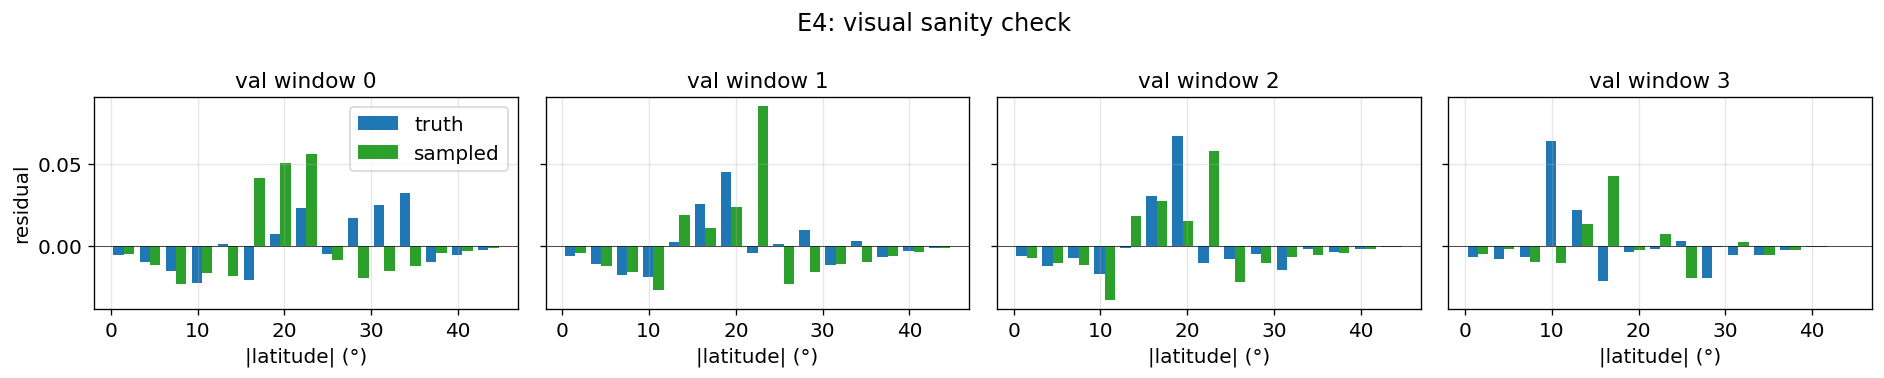

In [217]:
if not TRAIN_MODE:
    print("Skipping Part D visual sanity check (MODE=eval). Switch MODE to \"train\" to run this cell.")
else:
    # Part D — quick overlay for the most recently trained checkpoint.

    if not ENABLED_EXPERIMENTS:
        print("No experiments were trained this session — nothing to visualize.")
    else:
        _name = ENABLED_EXPERIMENTS[-1]
        _cfg  = EXPERIMENTS[_name]
        lit, _, val_ds, _ = load_trained_experiment(
            _name, _cfg, windows_aug, CKPT_DIR, alpha_np, sigma_np,
        )

        n_show = 4
        cond_concat = torch.cat(
            [torch.stack([val_ds[i][k] for i in range(n_show)])
             for k in _cfg["consumed_keys"]],
            dim=-1,
        )
        truth = torch.stack([val_ds[i]["r_clean"] for i in range(n_show)]).numpy()
        truth_phys = truth * val_ds.bin_stds.numpy() + val_ds.bin_means.numpy()
        samples = sample_conditional_extended(lit, cond_concat, guidance_w=0.0).cpu().numpy()

        fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3.2), sharey=True)
        for i, ax in enumerate(axes):
            w = BIN_WIDTH * 0.4
            ax.bar(BIN_CENTERS - w / 2, truth_phys[i], width=w, color="C0", label="truth")
            ax.bar(BIN_CENTERS + w / 2, samples[i],    width=w, color="C2", label="sampled")
            ax.axhline(0, color="k", lw=0.4)
            ax.set_title(f"val window {i}")
            ax.set_xlabel("|latitude| (°)")
        axes[0].set_ylabel("residual"); axes[0].legend()
        fig.suptitle(f"{_name}: visual sanity check")
        fig.tight_layout(); plt.show()

<a id="eval-mode"></a>

---
# Evaluation mode — NLL ablations across all experiments (Tasks 67–70)

This is the evaluation half of the Week 10 extension. It scores every
checkpoint produced by train mode (`ckpt_E*.ckpt` in this directory)
against the same **hard-gated NLL** metric used in 10c, and adds a
critical new diagnostic: an **oracle MLP** that maps each experiment's
cond vector directly to per-bin Gaussian residual parameters. The
oracle's NLL is an *upper bound* on what any model can extract from a
given cond set:

- Diffusion ≪ oracle  →  architecture is the bottleneck (try FiLM, CFG, Fourier).
- Oracle ≈ classical  →  the cond set itself doesn't help; try a different
  cond group or stop running that variant.

This is what makes the ablation scientifically honest: without an
oracle, a flat NLL across experiments could mean *either* "more cond
doesn't help" *or* "the architecture can't extract the new cond's
information" — two completely different fixes.

*The code cells below only execute when `MODE == "eval"`.*


---
## Task 67 — Build per-window evaluation blocks

Re-window the raw CSV the same way 10c does (per-window, 6-monthly,
≥ 20 obs per window) and tag each window with its v2 parquet row's
*entire* cond superset — every group, normalized later per-experiment
using the corresponding checkpoint's `cond_<g>_means` / `cond_<g>_stds`
buffers. We work with **per-window blocks only** in 10e — that is the
granularity at which the diffusion model is native, and the granularity
where any improvement over Week 10 will be most visible.


In [ ]:
if not EVAL_MODE:
    print("Skipping Task 67 Part 1 (per-window blocks) (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 67 — per-window blocks tagged with their v2 cond superset.
    #
    # Goal: rebuild per-window evaluation blocks for every (cycle, hemisphere)
    # in train+val, identical to the per-window construction in 10c, and tag
    # each block with the *raw* (unnormalized) vector from each cond group in
    # the v2 parquet. Downstream cells normalize per-experiment using each
    # checkpoint's buffers via `block_cond_concat`.
    #
    # Reference: 10c uses a 6-monthly window with min 20 obs per window.
    #
    # Expected outputs:
    #   GROUP_COLS  — dict mapping group name ("base", "cyclehemi", "opp",
    #                 "traj") → list of column names in windows_v2.
    #                 Resolve "traj" dynamically from columns starting with
    #                 "area_lag".
    #   hemicycles  — list of dicts, one per hemicycle, carrying a "blocks"
    #                 list. Each block dict must include:
    #                   "center_decimal", "tau", "lats" (np.ndarray of |lat|),
    #                   "groups_raw" (dict group → raw float32 vector).
    #                 Each hemicycle dict must include "cycle", "hemisphere",
    #                 "amplitude", "t0", "split", "blocks".

    raw_df = pd.read_csv(paths["raw_csv"])
    # TODO: parse dates, compute abs_lat, derive hemisphere, drop missing CYCLE.

    # TODO: define GROUP_COLS (see ExtendedConditionalResidualDataset.GROUP_COLS
    #       in conditioned_infrastructure.py for the schema).

    # TODO: build a per-window cond lookup keyed by (cycle, hemisphere, year_center).

    # TODO: build_per_window_hc(cyc, hemi, df_hc) — returns the block list for
    #       one hemicycle (mirror 10c's window construction).

    hemicycles = []  # TODO: populate
    assert len(hemicycles) > 0, "rebuild the per-window blocks before continuing"
    assert all("groups_raw" in blk for hc in hemicycles for blk in hc["blocks"]), \
        "every block needs a groups_raw dict"
    print(f"per-window blocks built: {sum(len(hc['blocks']) for hc in hemicycles)}")
    print(f"hemicycles included    : {len(hemicycles)}")


---
## Task 67 (cont) — NLL primitives, same as 10c

These are byte-identical to the primitives in 10c. Re-stated here so
10e can be run standalone (without executing 10c first).


In [ ]:
if not EVAL_MODE:
    print("Skipping Task 67 Parts 2-3 (hard NLL primitives) (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 67 — hard NLL primitives. Port from 10c (or import them if you've
    # factored them out). The two callables you need are:
    #
    #   hard_nll_classical(model, hcs) -> (nll, detail)
    #   hard_nll_combined (model, hcs, residuals_by_block, eps=1e-6)
    #                                                  -> (nll, detail)
    #
    # 10c defines both; they are byte-identical here. Once defined, the
    # print below should report a classical baseline near 10c's val number.

    # TODO: define hard_nll_classical and hard_nll_combined.

    val_hcs = [hc for hc in hemicycles if hc["split"] == "val"]
    nll_cl_val, det_cl_val = hard_nll_classical(classical, val_hcs)
    print(f"classical hard NLL (val): {nll_cl_val:.4f}  "
          f"(coverage {det_cl_val['coverage']:.3f})")


---
## Task 67 (cont) — Diagnostic oracle

For each experiment's cond set, fit a tiny MLP that maps the cond
vector directly to a 15-D Gaussian over the residual bins
(`mean`, `log_std`). The oracle's NLL is computed by sampling K
residuals from the per-block Gaussian and feeding them through
`hard_nll_combined` — the same harness used to score the diffusion.

What the oracle answers:

- **Diffusion ≪ oracle**  →  the diffusion isn't extracting the
  information that's already in the cond. Try a stronger architecture
  (FiLM, Fourier features, larger MLP).
- **Oracle ≈ classical**  →  the cond set itself doesn't carry enough
  information about the residual structure. Try a different cond
  group or stop adding to this one.

You implement this. The science (the tiny MLP, the Gaussian NLL
expression, the training loop, sampling from the predicted Gaussian)
is yours.

In [ ]:
# Task 67 — the oracle MLP. Students fill in the bodies below.

class OracleMLP(nn.Module):
    """Map a cond vector to per-bin Gaussian residual params (mean, log_std).

    Output is 2 * 15 = 30 numbers per row: 15 means + 15 log-stds.
    """
    def __init__(self, cond_dim, hidden_dim=64):
        super().__init__()
        # TODO: build a 2–3 layer MLP with SiLU activations.
        raise NotImplementedError("Task 67 — implement OracleMLP.__init__")

    def forward(self, cond):
        # TODO: return (mean, log_std), each shape (B, 15).
        raise NotImplementedError("Task 67 — implement OracleMLP.forward")


def gaussian_nll(r, mean, log_std):
    """Per-row, per-bin Gaussian NLL of the *standardized* residual ``r``
    under the predicted ``(mean, log_std)``. Return a scalar."""
    # TODO: implement the closed-form Gaussian NLL.
    raise NotImplementedError("Task 67 — implement gaussian_nll")


def fit_oracle(cond_train, r_train, cond_val, r_val,
               max_epochs=500, lr=1e-2, hidden_dim=64, seed=0):
    """Fit OracleMLP on (cond_train, r_train); track val NLL each epoch
    and return the module with the best val state restored, along with
    the best val NLL. ``r_*`` are *standardized* residuals (15-D)."""
    # TODO: instantiate OracleMLP, an Adam optimizer, and a training
    #       loop with early stopping on best val gaussian_nll.
    raise NotImplementedError("Task 67 — implement fit_oracle")

---
## Task 68 — Score every checkpoint

For each discovered `ckpt_E*.ckpt`:

1. Build per-experiment cond tensors for every val block by
   concatenating the right groups in `consumed_keys` order, normalized
   with the **checkpoint's own** per-group buffers (so val data uses
   train-set normalization recovered from the saved model).
2. Run K = 100 conditional samples per block using
   `sample_conditional_extended`. For E6 (CFG), repeat the sampling at
   every guidance weight in `CFG_GUIDANCE_W` and keep them as separate
   rows.
3. Fit the oracle MLP on the same (cond, standardized residual) data
   and record its val NLL as the upper bound for this cond set.
4. Plug each of the K samples into `hard_nll_combined`; report mean
   and σ over K.


In [ ]:
# Task 68 — score every discovered checkpoint.

K = 100   # K samples per val block; bump to 500 for tighter K-σ bars.

# Guidance values to sweep when scoring a CFG-trained checkpoint.
CFG_GUIDANCE_W = [1.0, 1.5, 2.0, 3.0]


def score_checkpoint(name, cfg):
    """Score one experiment.

    The recipe:
      1. Load the trained model + datasets via
         `load_trained_experiment(name, cfg, windows_aug, _WEEK10_DIR,
                                  alpha_np, sigma_np)`.
      2. Build per-val-block cond tensors via
         `block_cond_concat(val_hcs, lit, cfg, train_ds)`,
         repeat each row K times, and sample residuals with
         `sample_conditional_extended(lit, cond_K, guidance_w=w,
                                       device=device)`.
         If `cfg["cond_dropout_p"] > 0`, sweep every `w` in
         `CFG_GUIDANCE_W` and emit one row per `w`; otherwise sample
         once at `w = 0.0`.
      3. Reshape samples to (N, K, 15) physical units; push them through
         `k_run_combined(hard_nll_combined, classical, val_hcs, keys,
                          samples_NK15)` to get K NLLs and floor
         fractions.
      4. Fit the oracle on the same cond set: build (cond, residual)
         pairs for train and val blocks, standardize residuals with the
         train-set bin stats, and call `fit_oracle`. Convert the
         oracle's per-block Gaussian into K physical-unit samples and
         push them through `k_run_combined` to get the oracle's
         hard-NLL upper bound.

    Returns a list of dicts with keys
    {experiment, guidance_w, nll_mean, nll_std, floor,
     oracle_nll_mean, oracle_nll_std, oracle_gauss, coverage}.
    """
    # TODO: implement the four steps above.
    raise NotImplementedError("Task 68 — implement score_checkpoint")


In [ ]:
if not EVAL_MODE:
    print("Skipping Task 68 scoring loop (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Discover trained checkpoints and score them.
    _ckpts = discover_experiment_checkpoints(_WEEK10_DIR)
    for name in _ckpts:
        assert name in EXPERIMENTS, (
            f"ckpt_{name}.ckpt has no entry in EXPERIMENTS — add a spec to Task 65 "
            f"(both halves of this notebook share the same dict)."
        )
    print(f"discovered checkpoints: {list(_ckpts)}")

    all_rows = []
    for name in _ckpts:
        print(f"scoring {name} ...")
        all_rows.extend(score_checkpoint(name, EXPERIMENTS[name]))

    scoreboard = pd.DataFrame(all_rows)
    scoreboard["classical"] = nll_cl_val
    print(scoreboard.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


---
## Task 69 — Headline plot

Bar chart, val split: classical baseline plus every experiment's NLL,
with K-σ error bars. Oracle NLL per experiment overlaid as a
horizontal dashed marker to make the "what's achievable from this cond
set" boundary visible.

For any CFG variant (`cond_dropout_p > 0`), the bar shown is the
best-NLL guidance setting; a secondary panel sweeps the guidance
weight `w` so you can see the guidance vs NLL trade.

In [ ]:
if not EVAL_MODE:
    print("Skipping Task 69 headline plot (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 69 — headline plot + CFG sweep + per-hemicycle breakdown.
    #
    # Required panels:
    #   1. Bar chart of val NLL: classical bar on the left, one bar per
    #      experiment (best guidance w if it's a CFG variant), with K-σ
    #      error bars. Overlay each experiment's oracle NLL as a dashed
    #      horizontal marker so the "what's achievable from this cond set"
    #      boundary is visible.
    #   2. (If any CFG checkpoint exists) a sweep of guidance weight vs NLL
    #      on the CFG variant.
    #   3. Per-hemicycle breakdown for the best variant — same axes as the
    #      Week 10 chart so any improvement is visually unambiguous.
    #
    # Useful values you already have:
    #   - `scoreboard` (DataFrame from Task 68)
    #   - `nll_cl_val` (classical baseline)
    #   - `val_hcs`, `EXPERIMENTS`, `K`, `_WEEK10_DIR`
    #
    # For panel 3, reuse `load_trained_experiment(...)`,
    # `block_cond_concat(...)`, `sample_conditional_extended(...)`, and
    # `k_run_combined(...)`.

    # TODO: build the three panels.
    pass  # remove when you implement the panels above


---
## Task 70 — Going further

Once you've worked through the Level 1–5 escalation menu in 10d and
want to push further, the tiered menu below ranks the next experiments
by expected payoff per unit effort. Discipline still applies: one knob
at a time, log to wandb, add to `EXPERIMENTS` in both 10d and 10e,
then re-run.

**Level 1 — easy wins**
- **Wider/deeper MLP.** Bump `hidden_dim` from 128 to 256, `n_layers`
  from 3 to 5 in the winning experiment's config. If NLL drops, the
  network was capacity-bound — interesting on its own.
- **Longer K at evaluation.** Bump K from 100 to 500 for the winning
  variant — tightens the K-σ error bar and lets you trust smaller
  margins.
- **Sampler comparison.** Re-score the winner with DDPM (stochastic)
  sampling instead of the deterministic DDIM in
  `sample_conditional_extended`. Deterministic samplers can under-
  disperse, inflating NLL.

**Level 2 — extra cond information**
- **Larger trajectory K.** Bump `K_LAGS` from 4 to 8 in 10d. If the
  trajectory variant's oracle improves but its diffusion doesn't, the
  architecture is underusing the longer history.
- **Lagged opposite-hemisphere.** Pair the trajectory cond with the
  opposite hemisphere — `opp_area_smoothed_lag1..lag4`.

**Level 3 — architectural changes**
- **Cross-attention conditioning.** Replace the FiLM mechanism with
  cross-attention over a small set of learned cond tokens — overkill
  for the cond dim here, but worth knowing if the FiLM gain saturates.
- **Per-bin-aware loss.** Weight the ε-prediction loss by the inverse
  per-bin std so well-resolved bins don't dominate gradients.

**The test set is the PI's.** Every iteration above is val-only. The
final test-set reveal happens once, after the program is closed.

---
## Handoff back to the PI

The headline numbers in `scoreboard` answer two questions:

1. **Does any variant beat the classical baseline on val?** If yes, the
   diffusion approach has earned its place in the final pipeline.
2. **Where is the bottleneck — information or architecture?** Compare
   each row's `nll_mean` to its `oracle_nll_mean`. A large gap means
   the cond set has more information than the diffusion is extracting
   (architecture-bound). A small gap with the oracle near classical
   means the cond set isn't carrying enough information — that line of
   experiments is exhausted; try a different cond group.

The PI will run the test set evaluation on whatever variant the val
results recommend.
